In [ ]:
#importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#importing dataset
df = pd.read_csv('Genetic_disorder.csv')

DATA INSPECTION

In [ ]:
df.shape

(5585, 45)

In [ ]:
df.head(3)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x8ce3,11.0,No,No,Yes,No,5.209058,Willie,Camacho,Tr,...,Multiple,6.669552,slightly abnormal,1.0,1.0,1.0,0.0,1.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
1,PID0x8660,4.0,No,Yes,Yes,Yes,4.752272,John,Sandoval,Gregori,...,Multiple,6.397702,abnormal,0.0,0.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
2,PID0x7678,6.0,Yes,No,Yes,No,4.620420,Ruth,Homza,Cesareo,...,Multiple,3.000000,slightly abnormal,1.0,0.0,1.0,0.0,1.0,Mitochondrial genetic inheritance disorders,Leigh syndrome


In [ ]:
df.isna().sum()

,0
Patient Id,0
Patient Age,0
Genes in mother's side,0
Inherited from father,0
Maternal gene,0
Paternal gene,0
Blood cell count (mcL),0
Patient First Name,0
Family Name,0
Father's name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,5585.000000,5585.000000,5585.000000,5585.000000,5585.0,5585.0,5585.0,5585.0,5585.0,5585.000000,5585.000000,5585.000000,5585.000000,5585.000000,5585.000000,5585.000000
mean,6.916562,4.901093,34.711549,41.989794,0.0,0.0,0.0,1.0,0.0,2.004476,7.413868,0.586750,0.551477,0.543599,0.496509,0.469651
std,4.354565,0.199098,9.826889,12.968833,0.0,0.0,0.0,0.0,0.0,1.409831,2.648672,0.492461,0.497388,0.498140,0.500033,0.499123
min,0.000000,4.146230,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.768235,26.000000,31.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.362171,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899601,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.356993,1.000000,1.000000,1.000000,0.000000,0.000000
75%,11.000000,5.036165,43.000000,53.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.449252,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.describe( include ='object')

,Patient Id,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Patient First Name,Family Name,Father's name,Institute Name,Location of Institute,...,Folic acid details (peri-conceptional),H/O serious maternal illness,H/O radiation exposure (x-ray),H/O substance abuse,Assisted conception IVF/ART,History of anomalies in previous pregnancies,Birth defects,Blood test result,Genetic Disorder,Disorder Subclass
count,5585,5585,5585,5585,5585,5585,5585,5585,5585,5585,...,5585,5585,5585,5585,5585,5585,5585,5585,5585,5585
unique,5585,2,2,2,2,1348,3463,5166,27,26,...,2,2,4,4,2,2,2,4,3,9
top,PID0x9aad,Yes,No,Yes,No,James,Smith,Kai,Not applicable,-,...,Yes,No,No,-,Yes,Yes,Singular,normal,Mitochondrial genetic inheritance disorders,Leigh syndrome
freq,1,3351,3355,3135,3159,113,74,3,2796,2796,...,2835,2849,1443,1433,2852,2847,2804,1452,2867,1428


In [ ]:
df['Maternal gene'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Paternal gene'].unique()

array(['No', 'Yes'], dtype=object)

DATA CLEANING

In [ ]:
#Removing spaces from within varibale names for effective data analysis
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

In [ ]:
#filtering out irrelevant columns
drop_col = df.columns[[0,7,8,9,10,11]]
df1 = df.drop(columns = drop_col)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 39 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   patient_age                                       5585 non-null   float64
 1   genes_in_mother's_side                            5585 non-null   object 
 2   inherited_from_father                             5585 non-null   object 
 3   maternal_gene                                     5585 non-null   object 
 4   paternal_gene                                     5585 non-null   object 
 5   blood_cell_count_(mcl)                            5585 non-null   float64
 6   institute_name                                    5585 non-null   object 
 7   location_of_institute                             5585 non-null   object 
 8   status                                            5585 non-null   object 
 9   respiratory_rate_(b

In [ ]:
#Renaming Variables appropriately
df1.rename(columns={'blood_cell_count_(mcl)': 'blood_cell_count',
                   'respiratory_rate_(breaths/min)': 'respiratory_rate',
                   'heart_rate_(rates/min': 'heart_rate',
                   'autopsy_shows_birth_defect_(if_applicable)': 'autopsy_shows_birth_defect',
                   'folic_acid_details_(peri-conceptional)': 'folic_acid_details',
                   'h/o_serious_maternal_illness':'ho_serious_maternal_illness',
                   'h/o_radiation_exposure_(x-ray)': 'ho_radiation_exposure',
                   'h/o_substance_abuse': 'ho_substance_abuse',
                   'assisted_conception_ivf/art': 'assisted_conception_ivf_art',
                   'white_blood_cell_count_(thousand_per_microliter)': 'white_blood_cell_count',
                    'follow-up':'follow_up'}, inplace=True)


In [ ]:
df1.respiratory_rate

,respiratory_rate
0,Tachypnea
1,Tachypnea
2,Tachypnea
3,Normal (30-60)
4,Tachypnea
...,...
5580,Normal (30-60)
5581,Normal (30-60)
5582,Tachypnea
5583,Normal (30-60)


In [ ]:
##filtering out more irrelevant columns based on neccessity, inappropriate and incorrect use of medical terms and values, to reduce noise
drop = df1.columns[[1,2,7,9,11,12,13,14,15,16,19,20,21,22,23,24,25,26,27,28,31,32,33,34,35,36]]
df2 = df1.drop(columns = drop)

In [ ]:
df2.describe(include='object')

,maternal_gene,paternal_gene,institute_name,status,heart_rate,follow_up,gender,birth_defects,genetic_disorder,disorder_subclass
count,5585,5585,5585,5585,5585,5585,5585,5585,5585,5585
unique,2,2,27,2,2,2,3,2,3,9
top,Yes,No,Not applicable,Alive,Normal,Low,Male,Singular,Mitochondrial genetic inheritance disorders,Leigh syndrome
freq,3135,3159,2796,3381,2838,2822,1912,2804,2867,1428


In [ ]:
df2.status.unique()

array(['Alive', 'Deceased'], dtype=object)

In [ ]:
df2.gender.unique()

array(['Male', 'Ambiguous', 'Female'], dtype=object)

#Exploratory Data Analysis


Univariate Analysis

Text(0.5, 1.0, 'Patient age distribution')

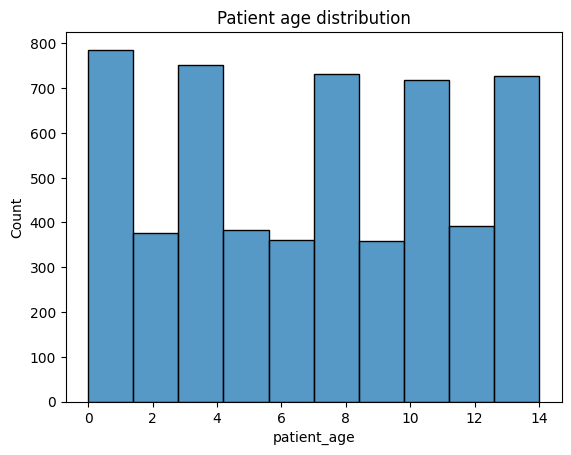

In [ ]:
sns.histplot(df2.patient_age, bins=10)
plt.title('Patient age distribution')

Text(0.5, 1.0, 'Red Blood cell count distribution')

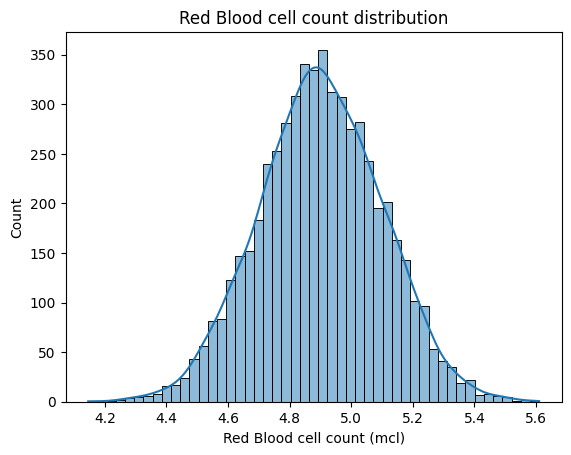

In [ ]:
sns.histplot(df2.blood_cell_count, kde=True)
plt.xlabel('Red Blood cell count (mcl)')
plt.title('Red Blood cell count distribution')

Text(0.5, 1.0, 'White Blood cell count distribution')

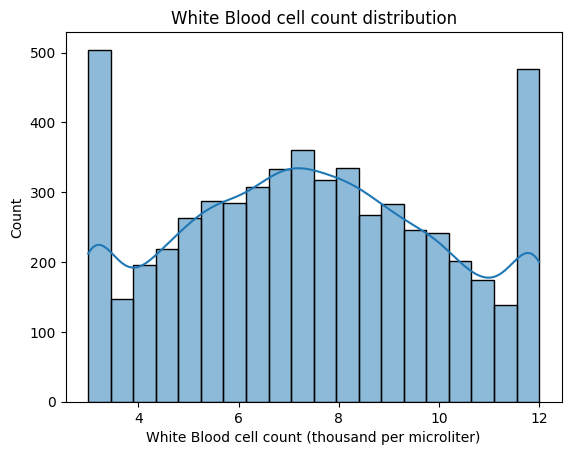

In [ ]:
sns.histplot(df2.white_blood_cell_count, kde=True)
plt.xlabel('White Blood cell count (thousand per microliter)')
plt.title('White Blood cell count distribution')

<function matplotlib.pyplot.show(close=None, block=None)>

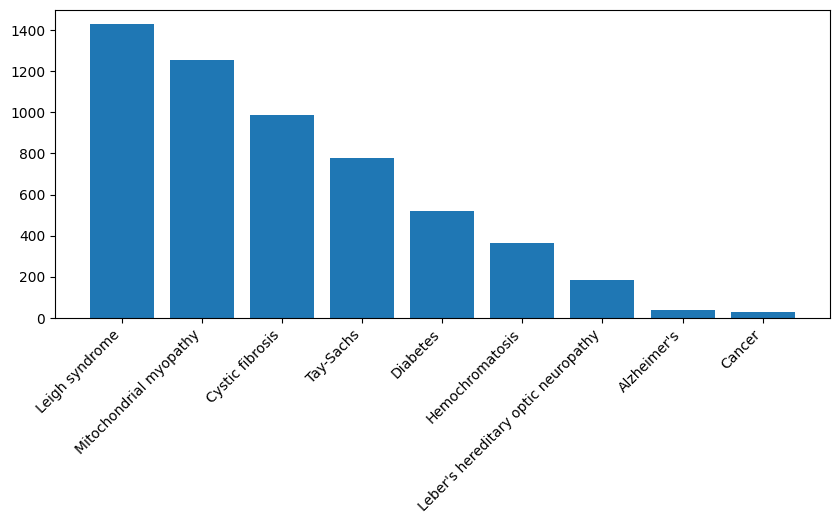

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(df2.disorder_subclass.value_counts().index, df2.disorder_subclass.value_counts())
plt.xticks(rotation=45, ha='right')
plt.show

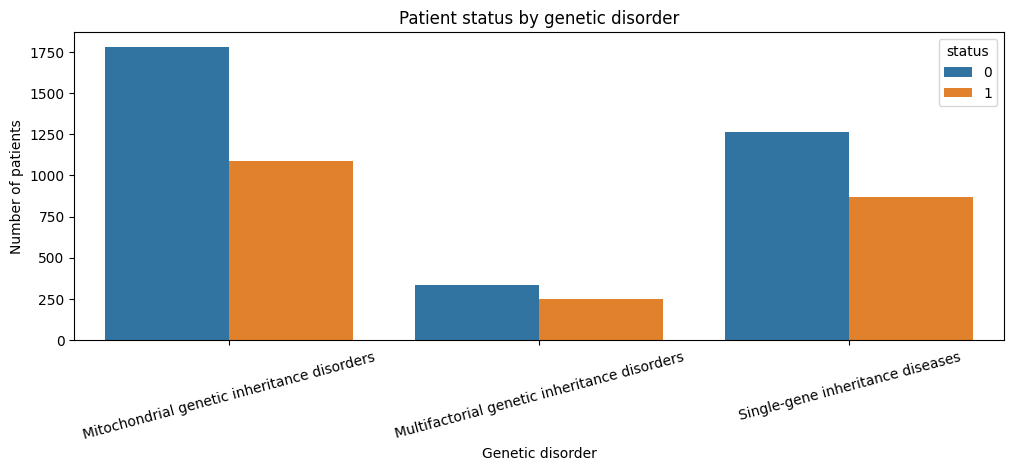

In [ ]:
plt.figure(figsize=(12,4))
sns.countplot(
    data=df2,
    x='genetic_disorder',
    hue='status'
)
plt.xticks(rotation=15)
plt.ylabel('Number of patients')
plt.xlabel('Genetic disorder')
plt.title('Patient status by genetic disorder')
plt.show()


<Axes: ylabel='patient_age'>

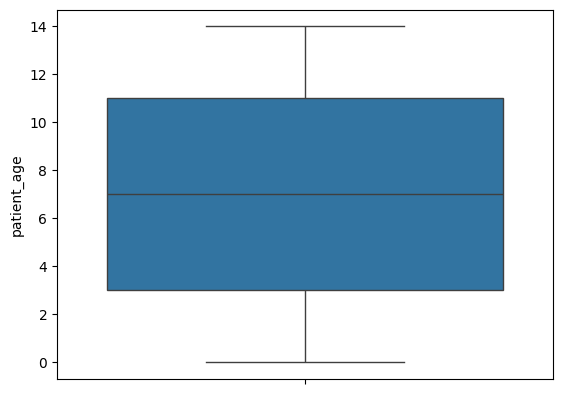

In [ ]:
sns.boxplot(data=df2.patient_age)

Bivariate Analysis

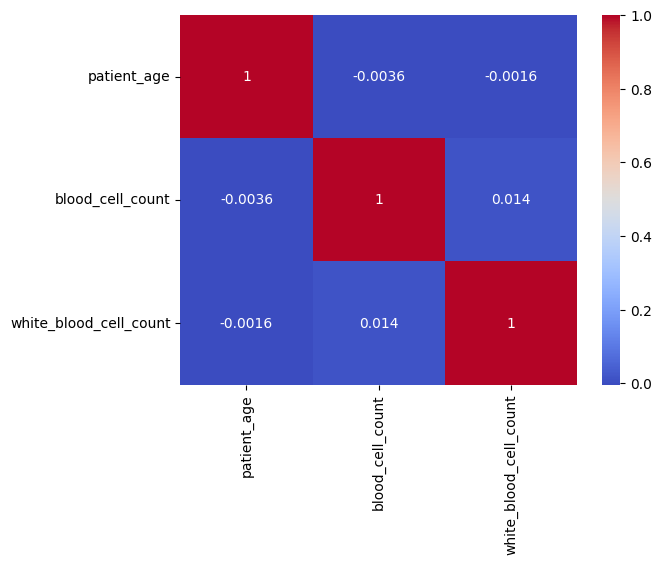

In [ ]:
sns.heatmap(df2.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

Multivariate Analysis

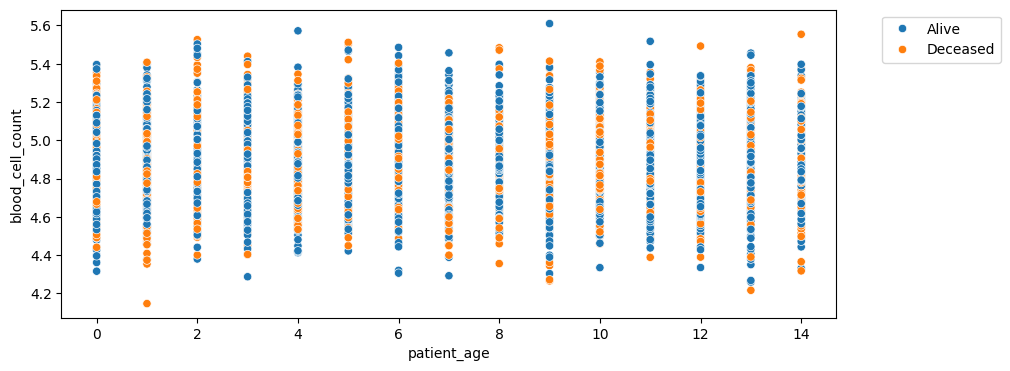

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(x='patient_age', y='blood_cell_count', data=df2, hue='status')
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)

#Data Pre-processing

In [ ]:
#Encoding two categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


df2.status=le.fit_transform(df2.status)
df2.maternal_gene=le.fit_transform(df2.maternal_gene)
df2.paternal_gene=le.fit_transform(df2.paternal_gene)
df2.heart_rate=le.fit_transform(df2.heart_rate)
df2.follow_up=le.fit_transform(df2.follow_up)
df2.birth_defects=le.fit_transform(df2.birth_defects)


In [ ]:
#Splitting the dataset into dependent(y) and independent variables(x)
x=df2.iloc[:,[0,1,2,3,4,6,7,8,9,10,11,12]]
y=df2.iloc[:,5]

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5585 entries, 0 to 5584
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_age             5585 non-null   float64
 1   maternal_gene           5585 non-null   int64  
 2   paternal_gene           5585 non-null   int64  
 3   blood_cell_count        5585 non-null   float64
 4   institute_name          5585 non-null   object 
 5   heart_rate              5585 non-null   int64  
 6   follow_up               5585 non-null   int64  
 7   gender                  5585 non-null   object 
 8   birth_defects           5585 non-null   int64  
 9   white_blood_cell_count  5585 non-null   float64
 10  genetic_disorder        5585 non-null   object 
 11  disorder_subclass       5585 non-null   object 
dtypes: float64(3), int64(5), object(4)
memory usage: 523.7+ KB


In [ ]:
#Encoding more than two categorical variable using one-hot encoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [7,10])], remainder='passthrough')
x= np.array(ct.fit_transform(x))

In [ ]:
#deleting non-categorical nominal variables
x= np.delete(x, [10,-1], axis=1)
x[0]

array([0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 11.0, 1, 0, 5.20905799917528, 1, 1,
       0, 6.669552178444405], dtype=object)

In [ ]:
# Splitting dataset, 80% for training and 20% for testing

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=200)

In [ ]:
# Normalizing data by scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train[:,[6,9,13]] = sc.fit_transform(x_train[:,[6,9,13]])
x_test[:,[6,9,13]] = sc.transform(x_test[:,[6,9,13]])


#Model Training and Evaluation

##SVM(support vector machines)

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state = 10)
classifier.fit(x_train, y_train)  #fitting svc model into the dataset

SVC(kernel='linear', random_state=10)

In [ ]:
y_pred = classifier.predict(x_test) #using the fitted model to predict the test data

In [ ]:
#Evaluating model performance based on accuracy, sensitiviy and specificity

from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)


print(f'Accuracy:\n {accuracy}')
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")

Accuracy:
 0.6141450313339302
Sensitivity: 0.000
Specificity: 1.000


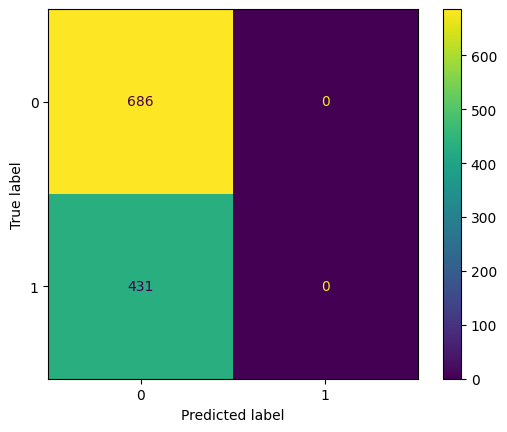

In [ ]:
#Visualising the Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()

##Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier1 = DecisionTreeClassifier(criterion = 'entropy', random_state = 10)
classifier1.fit(x_train, y_train) #fitting the decision tree model

DecisionTreeClassifier(criterion='entropy', random_state=10)

In [ ]:
#Evaluating model performance based on accuracy, sensitiviy and specificity

y_pred1 = classifier1.predict(x_test) #predicitng test data using the fitted model

accuracy1 = accuracy_score(y_test, y_pred1)
cm1 = confusion_matrix(y_test, y_pred1)

TN, FP, FN, TP = cm1.ravel()

sensitivity1 = TP / (TP + FN)
specificity1 = TN / (TN + FP)


print(f'Accuracy:\n {accuracy1}')
print(f"Sensitivity: {sensitivity1:.3f}")
print(f"Specificity: {specificity1:.3f}")

Accuracy:
 0.5058191584601611
Sensitivity: 0.387
Specificity: 0.580


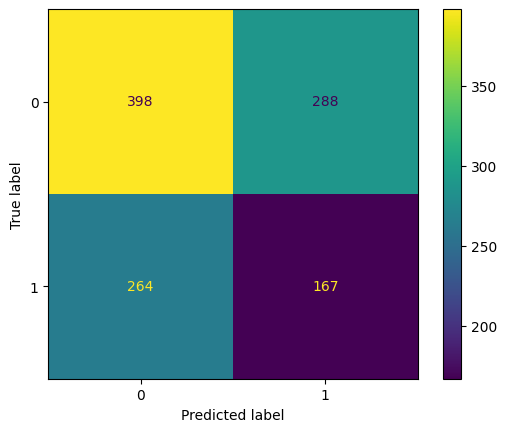

In [ ]:
#Visualising the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=classifier.classes_)
disp1.plot()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier2 = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 20)
classifier2.fit(x_train,y_train) #fitting the Random forest model

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=20)

In [ ]:
#Evaluating model performance based on accuracy, sensitiviy and specificity

y_pred2 = classifier2.predict(x_test) #predicting the test data with the fitted model

accuracy2 = accuracy_score(y_test, y_pred2)
cm2 = confusion_matrix(y_test, y_pred2)

TN, FP, FN, TP = cm2.ravel()

sensitivity2 = TP / (TP + FN)
specificity2 = TN / (TN + FP)


print(f'Accuracy:\n {accuracy2}')
print(f"Sensitivity: {sensitivity2:.3f}")
print(f"Specificity: {specificity2:.3f}")

Accuracy:
 0.5684870188003581
Sensitivity: 0.237
Specificity: 0.777


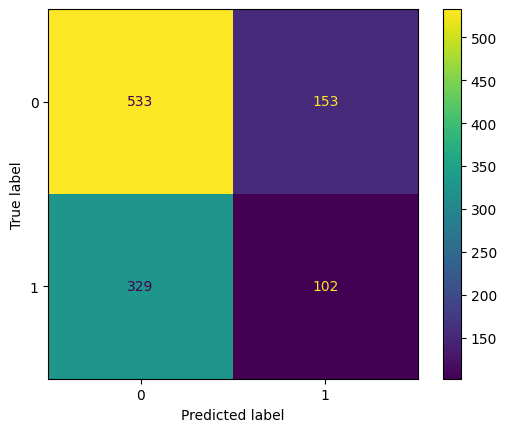

In [ ]:
#Visualising the confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classifier.classes_)
disp2.plot()